
<center>

# Customer Segmentation for a Kenyan Retail Chain

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 806 - Data Mining and Big Data
##### **Module:** Module 7 Clustering
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>

## Objective
A simple customer segmentation analysis using **synthetic customer data** for a Kenyan retail chain.

## Tasks covered
- Generate a synthetic customer dataset
- Preprocess the data
- Apply a clustering algorithm
- Visualize and interpret the clusters
- Suggest actionable recommendations

## Variables used
- `Age`
- `Monthly_Income_KES`
- `Monthly_Spend_KES`
- `Visits_Per_Month`

We use **K-Means clustering** because it is simple, easy to explain, and suitable for basic customer segmentation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)

## 1. Generate synthetic customer data

We create three broad customer groups:
- budget frequent shoppers
- middle-income regular shoppers
- premium shoppers


In [2]:
# Segment 1: budget frequent shoppers
n1 = 120
age1 = np.random.normal(29, 6, n1).clip(18, 60)
income1 = np.random.normal(28000, 7000, n1).clip(8000, 60000)
spend1 = np.random.normal(7000, 1800, n1).clip(1500, 15000)
visits1 = np.random.normal(9, 2, n1).clip(3, 16)

# Segment 2: middle-income regular shoppers
n2 = 110
age2 = np.random.normal(38, 7, n2).clip(22, 65)
income2 = np.random.normal(70000, 12000, n2).clip(30000, 120000)
spend2 = np.random.normal(18000, 3500, n2).clip(7000, 30000)
visits2 = np.random.normal(6, 1.5, n2).clip(2, 12)

# Segment 3: premium shoppers
n3 = 70
age3 = np.random.normal(44, 8, n3).clip(25, 70)
income3 = np.random.normal(160000, 30000, n3).clip(80000, 260000)
spend3 = np.random.normal(42000, 9000, n3).clip(18000, 70000)
visits3 = np.random.normal(4, 1.2, n3).clip(1, 9)

df = pd.DataFrame({
    "Age": np.concatenate([age1, age2, age3]).round().astype(int),
    "Monthly_Income_KES": np.concatenate([income1, income2, income3]).round(0),
    "Monthly_Spend_KES": np.concatenate([spend1, spend2, spend3]).round(0),
    "Visits_Per_Month": np.concatenate([visits1, visits2, visits3]).round(0)
})

df.head()

,Age,Monthly_Income_KES,Monthly_Spend_KES,Visits_Per_Month
0,32,33537.0,5573.0,10.0
1,28,21634.0,6793.0,12.0
2,33,37820.0,7909.0,9.0
3,38,18187.0,8558.0,10.0
4,28,32108.0,4839.0,10.0


## 2. Quick exploration

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,300.0,35.250000,8.908725,18.0,29.00,34.0,41.25,59.0
Monthly_Income_KES,300.0,76026.870000,55628.821373,13824.0,31207.00,63785.5,91317.00,224268.0
Monthly_Spend_KES,300.0,19434.456667,14773.056434,1500.0,7558.25,15836.5,22753.50,63631.0
Visits_Per_Month,300.0,6.933333,2.630327,1.0,5.00,7.0,9.00,15.0


## 3. Preprocessing

We standardize the features because income, spending, age, and visits are on different scales.


In [4]:
features = ["Age", "Monthly_Income_KES", "Monthly_Spend_KES", "Visits_Per_Month"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.36542044, -0.76508657, -0.93986083,  1.16783622],
       [-0.81516867, -0.9794159 , -0.85714007,  1.92946854],
       [-0.25298338, -0.68796546, -0.78147091,  0.78702006],
       [ 0.30920191, -1.04148371, -0.73746618,  1.16783622],
       [-0.81516867, -0.79081761, -0.98962889,  1.16783622]])

## 4. Choosing the number of clusters

We test values of **k** from 2 to 6 and compare silhouette scores.


In [5]:
scores = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

score_df = pd.DataFrame(scores, columns=["k", "silhouette_score"])
score_df

,k,silhouette_score
0,2,0.538283
1,3,0.408900
2,4,0.345196
3,5,0.311360
4,6,0.286500


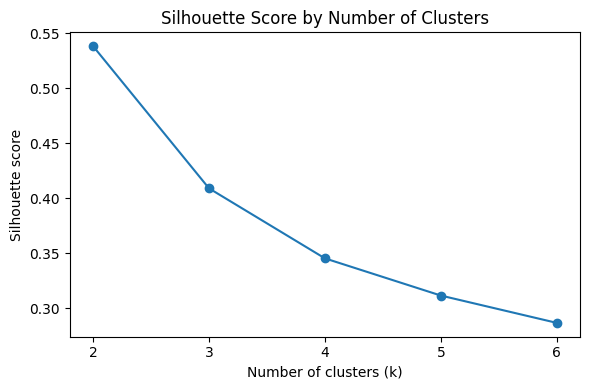

In [6]:
plt.figure(figsize=(6,4))
plt.plot(score_df["k"], score_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(score_df["k"])
plt.tight_layout()
plt.show()

We choose **k = 3** because it gives a strong and interpretable solution for this simple segmentation task.


## 5. Apply K-Means clustering

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Age,Monthly_Income_KES,Monthly_Spend_KES,Visits_Per_Month,Cluster
0,32,33537.0,5573.0,10.0,0
1,28,21634.0,6793.0,12.0,0
2,33,37820.0,7909.0,9.0,0
3,38,18187.0,8558.0,10.0,0
4,28,32108.0,4839.0,10.0,0


## 6. Cluster summary

In [8]:
cluster_summary = df.groupby("Cluster")[features].mean().round(1)
cluster_summary["Customer_Count"] = df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Monthly_Income_KES,Monthly_Spend_KES,Visits_Per_Month,Customer_Count
Cluster,,,,,
0,28.4,30218.4,7518.6,9.3,119
1,44.5,170149.8,44274.2,4.1,65
2,37.2,70278.7,17739.7,6.1,116


## 7. Visualize the segments

We use PCA to reduce the four variables into two components for plotting.


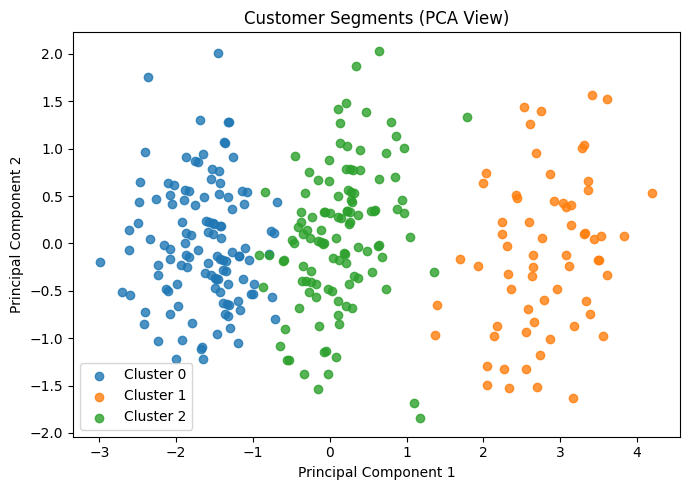

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}", alpha=0.8)

plt.title("Customer Segments (PCA View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Interpretation

- **Cluster 0: Budget frequent shoppers**  
  Lower income, lower spending, but relatively frequent visits.

- **Cluster 1: Middle-income regular shoppers**  
  Moderate income, moderate spending, and fairly regular shopping behavior.

- **Cluster 2: Premium shoppers**  
  Higher income, higher spending, and fewer but higher-value visits.


## 9. Actionable recommendations

### Cluster 0
- Offer low-cost bundles
- Promote staple products
- Use loyalty points for frequent visits

### Cluster 1
- Promote family-size packages
- Offer basket-size discounts
- Encourage monthly loyalty rewards

### Cluster 2
- Offer premium product promotions
- Use personalized messaging
- Build VIP-style loyalty benefits


## 10. Conclusion

The segmentation reveals meaningful customer groups that can support better targeting, pricing, promotions, and retention strategies.

Although the data is synthetic, the workflow is realistic and can be applied to real Kenyan retail transaction data.
